<img src="../../../figs/holberton_logo.png" alt="logo" width="500"/>


# OpenCV Fundamentals for Object Detection using YOLO

## Introduction

[OpenCV](https://opencv.org/) (Open Source Computer Vision Library) is an open-source computer vision and machine learning software library. It contains over 2500 optimized algorithms for various vision tasks. This tutorial will introduce you to the fundamentals of OpenCV and demonstrate how to perform object detection using the YOLO algorithm with sample images.

## Prerequisites

- Basic understanding of Python.
- Install OpenCV: `pip install opencv-python`
- Download YOLO weights and configuration files from the [official YOLO website](https://pjreddie.com/darknet/yolo/).

## Table of Contents

1. Introduction to OpenCV
2. Loading and Displaying Images
3. Basic Image Operations
4. Introduction to YOLO
5. Object Detection with YOLO
6. Practical Example with Sample Images

## 1. Introduction to OpenCV

OpenCV is designed for computational efficiency and with a strong focus on real-time applications. Below are some of the key functionalities of OpenCV:

- Image processing (filtering, transformations, etc.)
- Video analysis (object detection, tracking, etc.)
- Camera calibration
- 3D reconstruction

## 2. Loading and Displaying Images

First, let's load and display an image using OpenCV.


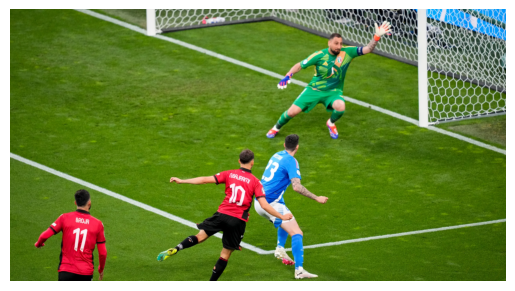

In [1]:
import cv2
from matplotlib import pyplot as plt

# Load an image from the yolo_images directory
image = cv2.imread('../yolo_images/yolo/goal.png')

# Convert the image from BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(image_rgb)
plt.axis('off')
plt.show()

## 3. Basic Image Operations

OpenCV allows you to perform various operations on images, such as resizing, cropping, and drawing shapes.

### Resizing

Resizing an image changes its dimensions, which is often necessary to meet the input requirements of different algorithms.

The **`cv2.resize` function adjusts the size of the image to the specified width and height**. This is particularly useful in deep learning applications where the input to the neural network must be of a fixed size.


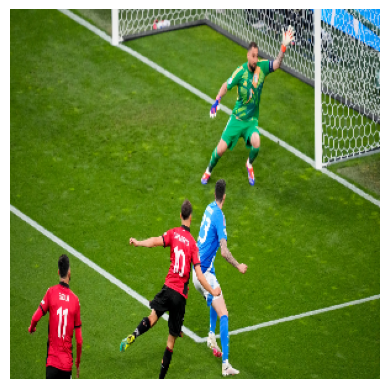

In [2]:
# Resize the image
resized_image = cv2.resize(image, (300, 300))

# Display the resized image
plt.imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


### Cropping

Cropping allows you to **cut out a specific region of the image**, which can be useful for focusing on an area of interest.

Cropping is performed by **specifying the range of rows and columns** to retain from the original image. This operation can help in isolating objects or regions within an image for closer analysis

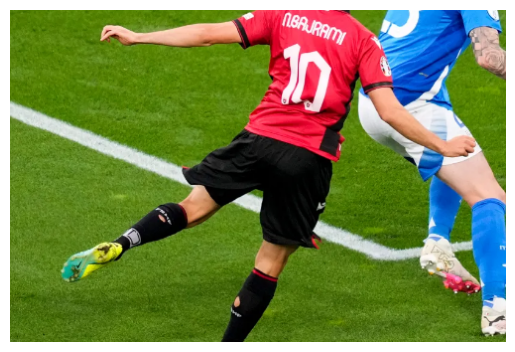

In [3]:
# Crop the image
cropped_image = image[500:900, 400:900]

# Display the cropped image
plt.imshow(cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


### Drawing shapes

Drawing shapes like rectangles, circles, or lines on images can be useful for **highlighting areas of interest**, such as detected objects.

The `cv2.rectangle` function is used to draw rectangles on images. It takes the **top-left and bottom-right** coordinates of the rectangle, the **color** (in BGR format), and the **thickness** of the rectangle's border as arguments. This is useful for visualizing bounding boxes around detected objects.

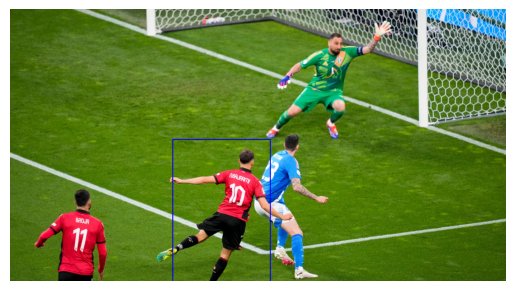

In [4]:
# Draw a rectangle on the image
image_with_rectangle = image.copy()
cv2.rectangle(image_with_rectangle, (500, 400), (800, 900), (255, 0, 0), 2)

# Display the image with a rectangle
plt.imshow(cv2.cvtColor(image_with_rectangle, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


### Image Normalization

Normalizing an image **scales the pixel values to a range that the neural network can process more effectively**.

Normalization involves scaling pixel values to a range of `0` to `1` (or `-1` to `1`) to improve the convergence speed and performance of the neural network during training and inference

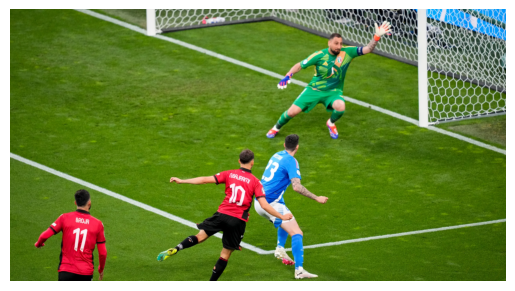

In [5]:
# Normalize the image
normalized_image = image / 255.0

# Display the normalized image
plt.imshow(cv2.cvtColor((normalized_image * 255).astype('uint8'), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


### Grayscale Conversion

Converting an image to grayscale reduces its complexity and can be useful for certain pre-processing tasks.

The `cv2.cvtColor` function with the `cv2.COLOR_BGR2GRAY` flag converts the image to grayscale, reducing the number of channels from three (BGR) to one. This is useful when color information is not necessary for the task

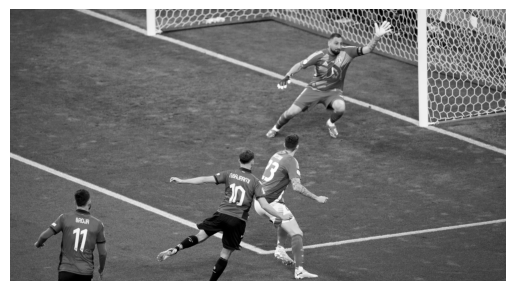

In [6]:
# Convert the image to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Display the grayscale image
plt.imshow(gray_image, cmap='gray')
plt.axis('off')
plt.show()


### Edge Detection

Edge detection **highlights the boundaries within an image**, which can be useful for identifying objects.

The `cv2.Canny` function performs edge detection by finding areas of rapid intensity change. This can help in identifying object boundaries and features within an image

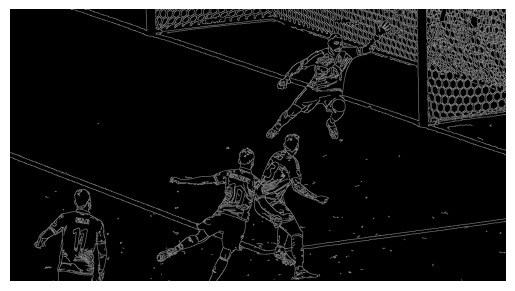

In [7]:
# Perform edge detection
edges = cv2.Canny(image, 100, 200)

# Display the edges
plt.imshow(edges, cmap='gray')
plt.axis('off')
plt.show()


### Blurring

Blurring an image can help in reducing noise and details, which can be useful for focusing on larger structures.

The `cv2.GaussianBlur` function applies a Gaussian blur to the image, which smooths out noise and reduces detail. This can help in pre-processing steps where noise reduction is needed.

The kernel size `(31, 31)` determines the width and height of the kernel matrix. Here’s how it works:

- **Kernel Dimensions**: The kernel is a matrix of size `31x31`. This means that the Gaussian blur operation will consider a `31x31` neighborhood around each pixel in the image to compute the blurred value of that pixel.
- **Odd Dimensions**: The dimensions must be positive and odd numbers. This is because the kernel needs to have a central pixel around which the weights are symmetrically distributed.
- **Effect of Kernel Size**: The larger the kernel size, the more the image will be blurred. A larger kernel means more neighboring pixels are considered in the blur calculation, leading to a smoother and more blurred image.

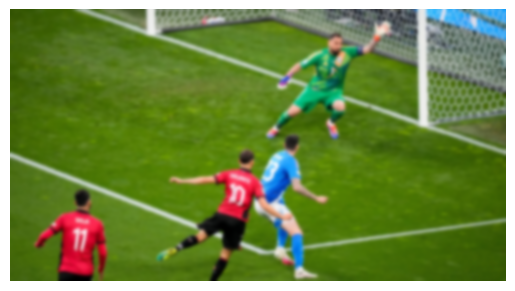

In [8]:
# Apply Gaussian blur
blurred_image = cv2.GaussianBlur(image, (31, 31), 0)

# Display the blurred image
plt.imshow(cv2.cvtColor(blurred_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


### Image Thresholding
Thresholding is a simple segmentation method used to separate objects from the background.

The `cv2.threshold` function converts grayscale images into binary images by applying a threshold value. Pixels with values above the threshold are set to the maximum value (`255`), and those below are set to `0`. This can help in isolating objects from the background.

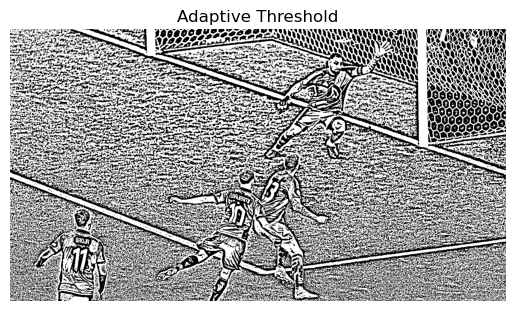

In [9]:
# Apply adaptive thresholding
adaptive_thresh = cv2.adaptiveThreshold(gray_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 21, 2)

# Display the adaptive thresholded image
plt.imshow(adaptive_thresh, cmap='gray')
plt.axis('off')
plt.title('Adaptive Threshold')
plt.show()


## 4. YOLOv3 Fundamentals

YOLOv3 is a **real-time object detection algorithm known for its speed and accuracy**. It works by dividing the image into a grid and predicting bounding boxes and class probabilities for each grid cell. Here's a breakdown of the key concepts and steps involved in using YOLOv3:

1. **Grid Division**: `YOLOv3` divides the input image into an `SxS` grid.
2. **Bounding Box Prediction**: Each grid cell predicts `B` bounding boxes, each with a confidence score.
3. **Class Prediction**: Each bounding box predicts `C` class probabilities.
4. **Non-Maximum Suppression (NMS)**: Redundant bounding boxes are eliminated to retain only the most accurate ones.

### Setting Up YOLOv3 in OpenCV

To use YOLOv3 with OpenCV, you need the following files:

- `YOLOv3` weights file (`yolov3.weights`)
- `YOLOv3` configuration file (`yolov3.cfg`)
- `COCO` names file (`coco.names`) which contains the list of class labels

### Step-by-Step Implementation

#### Step 1: Load YOLOv3 Model

This setup prepares the environment to perform object detection using `YOLOv3` with `OpenCV`. The model and class names are essential components for configuring and interpreting detections on input images or video streams.

- **Model loading**: `cv2.dnn.readNet` is used to load the YOLOv3 model architecture (`yolov3.cfg`) and pretrained weights (`yolov3.weights`). This initializes a neural network that is ready to perform object detection.
- **Class name loading**: `coco.names` contains the names of the classes that `YOLOv3` was trained to detect. These classes are read into a Python list (classes) for further use in labeling detected objects.
- **File handling**: `open('coco.names', 'r') as f` opens the file `coco.names` in read mode ('r'). Using with ensures that the file is properly closed after its suite finishes, even if an exception is raised.

In [10]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load YOLOv3 configuration and weights files
net = cv2.dnn.readNet('yolov3.weights', 'yolov3.cfg')

# Load class names
with open('coco.names', 'r') as f:
    classes = f.read().strip().split('\n')


#### Step 2: Prepare Input Image

The `cv2.dnn.blobFromImage` function preprocesses the input image by resizing it, normalizing pixel values, and converting it to a blob, which is the required format for the YOLOv3 network.

- **Read image**: reads the image `goal.png` from the specified path using `OpenCV`'s `imread` function.
- **Get image dimensions**: retrieves the height and width of the loaded image using the shape attribute of the image array.
- **Create a Blob from the Image**: prepares the image for input into the neural network by converting it into a blob. Parameters include scaling the pixel values to the range of `0` to `1`, resizing the image to (`416, 416`) pixels as required by YOLOv3, swapping red and blue channels (`swapRB=True`), and disabling cropping (`crop=False`). 

**Note:** *A blob, short for Binary Large Object, in the context of computer vision and deep learning, is a structured format for storing images*. 

The resulting blob is set as input to the neural network (`net.setInput(blob)`) for object detection.

In [26]:
# Load an image
image = cv2.imread('../yolo_images/yolo/goal.png')

# Get image dimensions
height, width = image.shape[:2]

# Create a blob from the image
blob = cv2.dnn.blobFromImage(image, 1/255.0, (416, 416), swapRB=True, crop=False)
net.setInput(blob)



#### Step 3: Perform Forward Pass and Obtain Detections

This sequence of operations prepares the network to generate predictions or detections based on the input image blob, leveraging the layers designated as outputs in the YOLOv3 model configuration.

- **Get the Output Layer Names**: `net.getLayerNames()` retrieves the names of all layers in the neural network. 
- `net.getUnconnectedOutLayers()` returns the indices of the output layers that are not connected to any other layers. These indices are used to fetch the corresponding output layer names from `layer_names`, creating `output_layers`.
- Perform Forward Pass: `net.forward(output_layers)` executes a forward pass through the neural network using the specified output_layers. 

**Note**: `net.getUnconnectedOutLayers()` is used to find the indices of specific output layers in a neural network model that do not send their outputs to any subsequent layers. This is crucial in architectures like YOLO, where these output layers directly produce the final detections or predictions.

This optimization avoids unnecessary computations on intermediate layers, making the inference process more efficient and faster.

In [23]:
# Get the output layer names
layer_names = net.getLayerNames()
output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers()]

# Perform forward pass
outputs = net.forward(output_layers)



#### Step 4: Process the Detections

In [24]:
# Initialize lists for detected bounding boxes, confidences, and class IDs
boxes = []
confidences = []
class_ids = []

# Iterate over each detection
for output in outputs:
    for detection in output:
        scores = detection[5:]
        class_id = np.argmax(scores)
        confidence = scores[class_id]

        if confidence > 0.5:
            # Scale bounding box coordinates to the original image size
            center_x = int(detection[0] * width)
            center_y = int(detection[1] * height)
            w = int(detection[2] * width)
            h = int(detection[3] * height)

            # Calculate top-left corner of the bounding box
            x = int(center_x - w / 2)
            y = int(center_y - h / 2)

            # Append to lists
            boxes.append([x, y, w, h])
            confidences.append(float(confidence))
            class_ids.append(class_id)



#### Step 5: Apply Non-Maximum Suppression

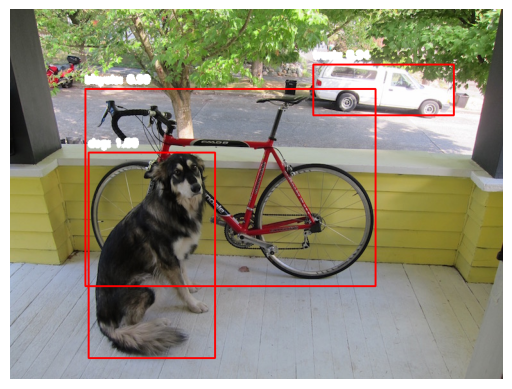

In [25]:
# Apply Non-Maximum Suppression
indices = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)

# Draw bounding boxes and labels on the image
if len(indices) > 0:
    for i in indices.flatten():
        box = boxes[i]
        x, y, w, h = box
        label = str(classes[class_ids[i]])
        confidence = confidences[i]

        # Draw the bounding box
        cv2.rectangle(image, (x, y), (x + w, y + h), (0, 0, 255), 2)

        # Display the label and confidence score
        text = f"{label}: {confidence:.2f}"
        cv2.putText(image, text, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 5)

# Display the output image
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

### Happy Coding